# 06 - Strategy-5 daughter grid against strategy 4

Strategy 4 (`qm_simpson_log`) puts the daughter momenta on a 20-decade Simpson grid; strategy 5
(`qm_acc_birth`) instead samples the birth scale factors a_q ∈ [a_min, 1] where daughters exist, with
`accdm_q_bins_per_decade` nodes per decade of a_q and a_min where the born fraction reaches
`accdm_q_number_tol` = 10⁻⁶. This checks that strategy 5 is as accurate as strategy 4 at a fraction of
the cost.

- **A.** One model, many grids, against strategy 4 with 2001 bins.
- **B.** A κ / a_t scan (small κ, κ = 1, late transitions up to a_t = 3), each against a fine
  strategy-5 run. Any NaN or failure is a bug.
- **C.** Convergence in bins/decade for late transitions (a_t = 1, 3), where B shows the largest errors.

The grid studied here is the even one in ln a_q (`accdm_q_log_share = 1`), as when strategy 5 was
introduced. The default since 2026-10-05 places 75% of the nodes by born fraction (s = 0.25,
notebooks 17–18); it is shown as one extra row in A and C.

**Result.**
- **A.** Strategy 5 at 50/decade (71 bins) is ~3× more accurate than strategy 4 with 501 bins and 10×
  faster: max |ΔP/P| 3·10⁻³ against 9·10⁻³ (k ≤ 1) and 4·10⁻² (k ≤ 10), TT 1·10⁻³ against 2.5·10⁻².
  The born-fraction default (s = 0.25) is better again (P 1·10⁻³, TT 5·10⁻⁴) and 20× faster. Below
  ~10⁻³ the 2001-bin reference itself limits the comparison (200/decade is not closer than 100).
- **B.** Every point runs without NaN, down to κ = 0.5 (a_min at the 10⁻¹⁴ floor) and up to a_t = 3. Against
  the fine reference the even grid is within 1.4·10⁻⁴–4.4·10⁻³ in P(k), s = 0.25 within 2.5·10⁻⁵–2.4·10⁻⁴.
- **C.** For late transitions the even grid converges slowly (1.2–1.6·10⁻³ at 50/decade, about halving
  per doubling); s = 0.25 reaches ~2·10⁻⁴ already at 50/decade.

Model: m = 10¹⁶ GeV, f_acc = 0.5, η = 10⁻⁵, κ = 12.1, a_t = 0.133 unless scanned, no sink. Cached in
`06_cache.pkl` (about 1 h from scratch, mostly the 2001-bin reference and the κ ≤ 1 fine runs).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from accdm_nb import KAPPA, A_T, RunCache, accdm_params, a_min, q_size, ok, status, show, plot_style

plot_style()

MASS, F_ACC = 1e16, 0.5
LMAX = 2500
K_PK = np.logspace(-3, 1, 60)              # 1/Mpc
Z_PK = (0.0, 2.0)
OUTPUT = {'output': 'tCl,pCl,mPk', 'l_max_scalars': LMAX, 'P_k_max_1/Mpc': 10.0, 'z_max_pk': 2.0,
          'reionization_z_start_max': 80, 'background_Nloga': 40000, 'acc_de_sink': 'no'}


def spectra(cosmo):
    cl = cosmo.raw_cl(LMAX)
    bg = cosmo.get_background()
    return {'pk0': np.array([cosmo.pk(k, 0.0) for k in K_PK]), 'pk2': np.array([cosmo.pk(k, 2.0) for k in K_PK]),
            'tt': np.asarray(cl['tt'])[2:], 'ee': np.asarray(cl['ee'])[2:], 'sigma8': cosmo.sigma8(),
            'Omega_acc': bg['(.)rho_ncdm[1]'][-1]/bg['(.)rho_crit'][-1]}


cache = RunCache('06_cache.pkl', extract=spectra)


def grid(strategy, bins=None, bpd=None, share=1, tol=None):
    """Daughter grid settings; share is accdm_q_log_share (1 = even in ln a_q)."""
    g = {'ncdm_quadrature_strategy': '0, {}'.format(strategy), 'accdm_q_log_share': share}
    if bins:
        g['ncdm_N_momentum_bins'] = '15, {}'.format(bins)
    if bpd:
        g['accdm_q_bins_per_decade'] = bpd
    if tol:
        g['accdm_q_number_tol'] = tol
    return g


def params(g, kappa=KAPPA, a_t=A_T):
    return accdm_params(F_ACC, MASS, kappa=kappa, a_t=a_t, **OUTPUT, **g)


def errors(rec, ref):
    """Max relative deviations of rec from ref."""
    out = {}
    for z in ('0', '2'):
        r = np.abs(rec['pk' + z]/ref['pk' + z] - 1)
        out['P z={} k≤1'.format(z)] = r[K_PK <= 1].max()
        out['P z={} k≤10'.format(z)] = r.max()
    out.update({s.upper(): np.max(np.abs(rec[s]/ref[s] - 1)) for s in ('tt', 'ee')})
    out.update({k: abs(rec[k]/ref[k] - 1) for k in ('sigma8', 'Omega_acc')})
    return out

## A. One model, many grids

Target: strategy 5 at its default density (50/decade) as accurate as strategy 4 with 501 bins (the
production grid before strategy 5) and at least 5× faster.

In [2]:
GRIDS_A = {'S4, 2001 bins (reference)': grid(4, bins=2001),
           'S4, 501 bins': grid(4, bins=501),
           'S5, 25/decade': grid(5, bpd=25),
           'S5, 50/decade (default)': grid(5, bpd=50),
           'S5, 100/decade': grid(5, bpd=100),
           'S5, 200/decade': grid(5, bpd=200),
           'S5, 50/decade, a_min at 1e-8': grid(5, bpd=50, tol=1e-8),
           'S5, 50/decade, s = 0.25': grid(5, bpd=50, share=0.25)}
amin = a_min()
print('a_min = {:.3e}; 50/decade = {} bins'.format(amin, q_size(50, amin)))

golden = dict(zip(GRIDS_A, cache.many([params(g) for g in GRIDS_A.values()])))
assert all(ok(r) for r in golden.values()), {k: status(r) for k, r in golden.items()}
ref, s4 = golden['S4, 2001 bins (reference)'], golden['S4, 501 bins']
table = pd.DataFrame([{'grid': lab, 'time [s]': r['sec'], 'speed-up vs S4 501': s4['sec']/r['sec'], **errors(r, ref)}
                      for lab, r in golden.items()]).set_index('grid')
show(table, {'time [s]': '{:.0f}', 'speed-up vs S4 501': '{:.1f}'}, default='{:.1e}')

a_min = 4.246e-02; 50/decade = 71 bins


8 new CLASS runs in 1460 s


,time [s],speed-up vs S4 501,P z=0 k≤1,P z=0 k≤10,P z=2 k≤1,P z=2 k≤10,TT,EE,sigma8,Omega_acc
grid,,,,,,,,,,
"S4, 2001 bins (reference)",1054,0.2,0.0e+00,0.0e+00,0.0e+00,0.0e+00,0.0e+00,0.0e+00,0.0e+00,0.0e+00
"S4, 501 bins",241,1.0,9.1e-03,4.2e-02,8.1e-03,6.0e-02,2.5e-02,1.3e-02,2.2e-03,1.2e-03
"S5, 25/decade",19,12.6,1.2e-02,4.6e-02,8.2e-03,5.6e-02,2.8e-03,1.4e-02,7.9e-04,1.1e-03
"S5, 50/decade (default)",23,10.3,3.3e-03,3.4e-03,4.4e-03,4.4e-03,1.3e-03,8.8e-03,4.5e-04,8.0e-07
"S5, 100/decade",45,5.4,1.8e-04,1.9e-04,2.4e-04,2.4e-04,2.3e-03,3.2e-04,2.6e-05,1.0e-06
"S5, 200/decade",54,4.4,1.0e-03,1.0e-03,1.4e-03,1.4e-03,1.9e-03,3.1e-03,1.4e-04,1.0e-06
"S5, 50/decade, a_min at 1e-8",12,20.0,2.0e-03,2.0e-03,2.6e-03,2.6e-03,2.9e-03,5.6e-03,2.7e-04,6.4e-08
"S5, 50/decade, s = 0.25",12,20.8,1.1e-03,1.1e-03,1.6e-03,2.2e-03,5.2e-04,2.9e-03,1.9e-04,5.9e-05


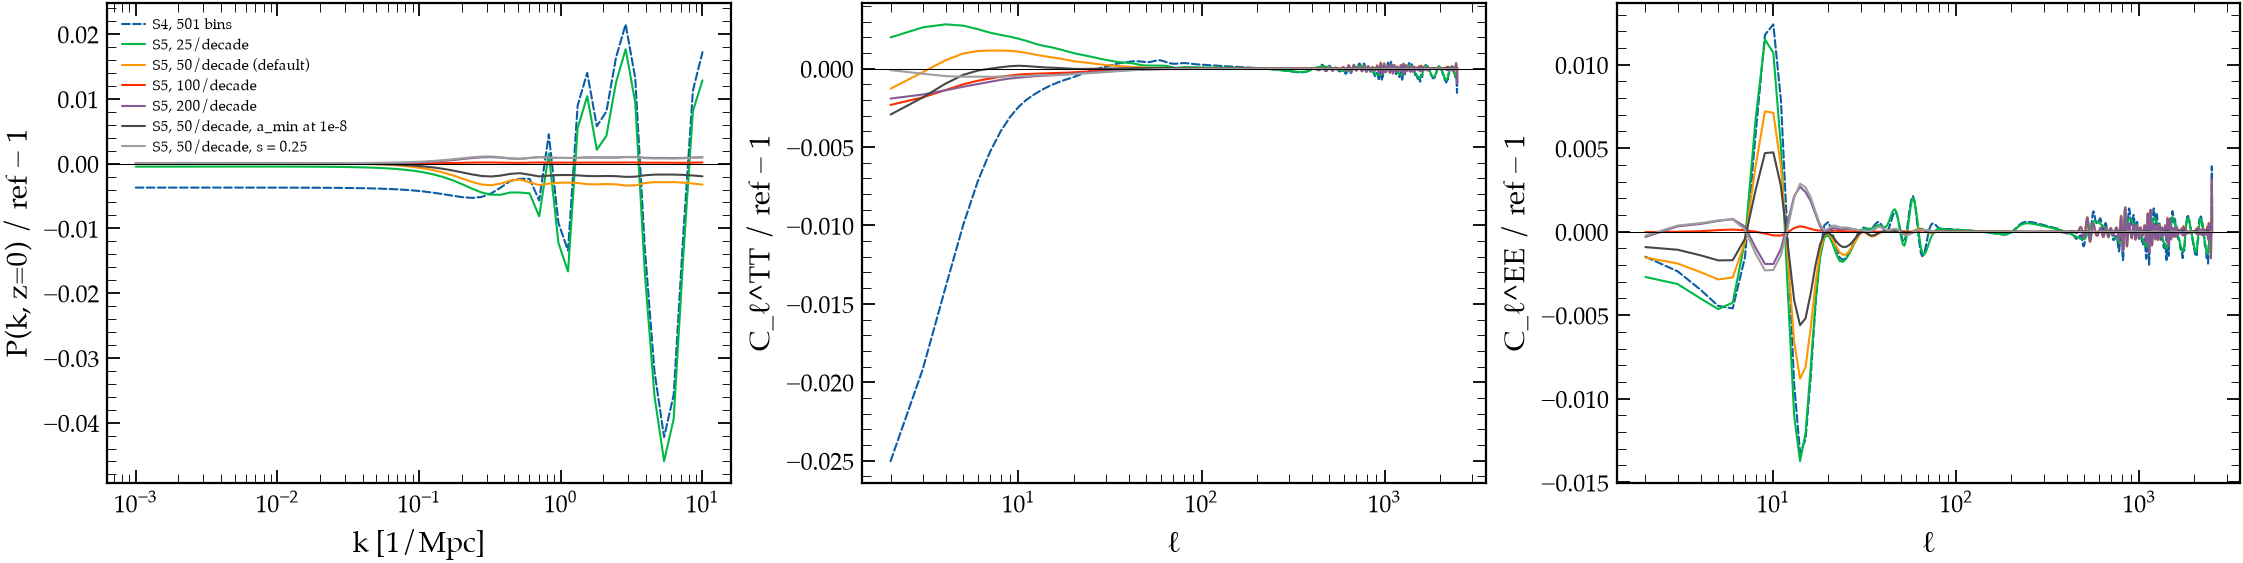

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), constrained_layout=True)
ell = np.arange(2, LMAX + 1)
for lab, r in golden.items():
    if lab.startswith('S4, 2001'):
        continue
    kw = dict(lw=1, ls='--' if 'S4' in lab else '-', label=lab)
    axes[0].semilogx(K_PK, r['pk0']/ref['pk0'] - 1, **kw)
    axes[1].plot(ell, r['tt']/ref['tt'] - 1, **kw)
    axes[2].plot(ell, r['ee']/ref['ee'] - 1, **kw)
axes[0].set_xlabel('k [1/Mpc]')
axes[0].set_ylabel('P(k, z=0) / ref − 1')
for ax, s in zip(axes[1:], ('TT', 'EE')):
    ax.set_xscale('log')
    ax.set_xlabel('ℓ')
    ax.set_ylabel('C_ℓ^{} / ref − 1'.format(s))
for ax in axes:
    ax.axhline(0, color='k', lw=0.5)
axes[0].legend(fontsize=7)
plt.show()

## B. κ / a_t scan

Each point runs strategy 5 at 50/decade, even and s = 0.25, against a fine strategy-5 run (200/decade,
a_min at 10⁻⁹). κ = 1 exercises the code's 0.99999 substitution; a_t = 3 puts the transition after
today; small κ pushes a_min to the 10⁻¹⁴ floor and gives the most bins.

In [4]:
SCAN = [(0.5, 0.13), (1.0, 0.13), (2.0, 0.13), (5.0, 0.13), (12.1, 0.133), (5.0, 0.5), (5.0, 1.0), (5.0, 3.0)]
GRIDS_B = {'S5 even': grid(5, bpd=50), 'S5 s=0.25': grid(5, bpd=50, share=0.25),
           'fine': grid(5, bpd=200, tol=1e-9)}
rows = []
for kappa, a_t in SCAN:
    recs = dict(zip(GRIDS_B, cache.many([params(g, kappa, a_t) for g in GRIDS_B.values()], verbose=False)))
    row = {'kappa': kappa, 'a_t': a_t, 'a_min': a_min(kappa, a_t), 'bins': q_size(50, a_min(kappa, a_t))}
    bad = [lab for lab, r in recs.items() if not ok(r)]
    if bad:
        rows.append({**row, 'status': '; '.join('{}: {}'.format(lab, status(recs[lab])) for lab in bad)})
        continue
    for lab in ('S5 even', 'S5 s=0.25'):
        e = errors(recs[lab], recs['fine'])
        row.update({lab + ', P k≤1': e['P z=0 k≤1'], lab + ', TT': e['TT']})
    rows.append({**row, 'time S5 [s]': recs['S5 even']['sec'], 'status': 'ok'})
scan = pd.DataFrame(rows).set_index(['kappa', 'a_t'])
show(scan, {'a_min': '{:.1e}', 'bins': '{:d}', 'time S5 [s]': '{:.0f}'}, default='{:.1e}')

a_min bins S5 even, P k≤1 S5 even, TT S5 s=0.25, P k≤1  \
kappa a_t                                                               
0.5   0.130  7.0e-14  659        1.4e-04     8.2e-04          2.8e-05   
1.0   0.130  1.2e-07  349        2.2e-04     5.2e-03          2.5e-05   
2.0   0.130  1.3e-04  197        4.3e-04     2.5e-03          5.9e-05   
5.0   0.130  8.2e-03  107        1.0e-03     2.3e-03          4.9e-05   
12.1  0.133  4.2e-02   71        4.4e-03     1.7e-03          1.1e-04   
5.0   0.500  3.1e-02   77        1.2e-03     1.7e-03          1.2e-04   
      1.000  5.5e-02   65        9.8e-04     7.5e-04          1.2e-04   
      3.000  6.3e-02   63        1.3e-03     9.3e-04          2.4e-04   

            S5 s=0.25, TT time S5 [s] status  
kappa a_t                                     
0.5   0.130       3.1e-04         131     ok  
1.0   0.130       5.5e-03          67     ok  
2.0   0.130       1.0e-03         159     ok  
5.0   0.130       1.2e-03          45     ok  
12.1  0.133       5.9e-04          23     ok  
5.0   0.500       2.6e-03          26     ok  
      1.000       6.4e-05          24     ok  
      3.000       9.9e-04          25     ok

## C. Late transitions

For a_t = 1 and 3, the errors of B fall slowly with node density. Ladder of bins/decade against an even
grid at 400/decade.

1 new CLASS runs in 233 s


1 new CLASS runs in 202 s


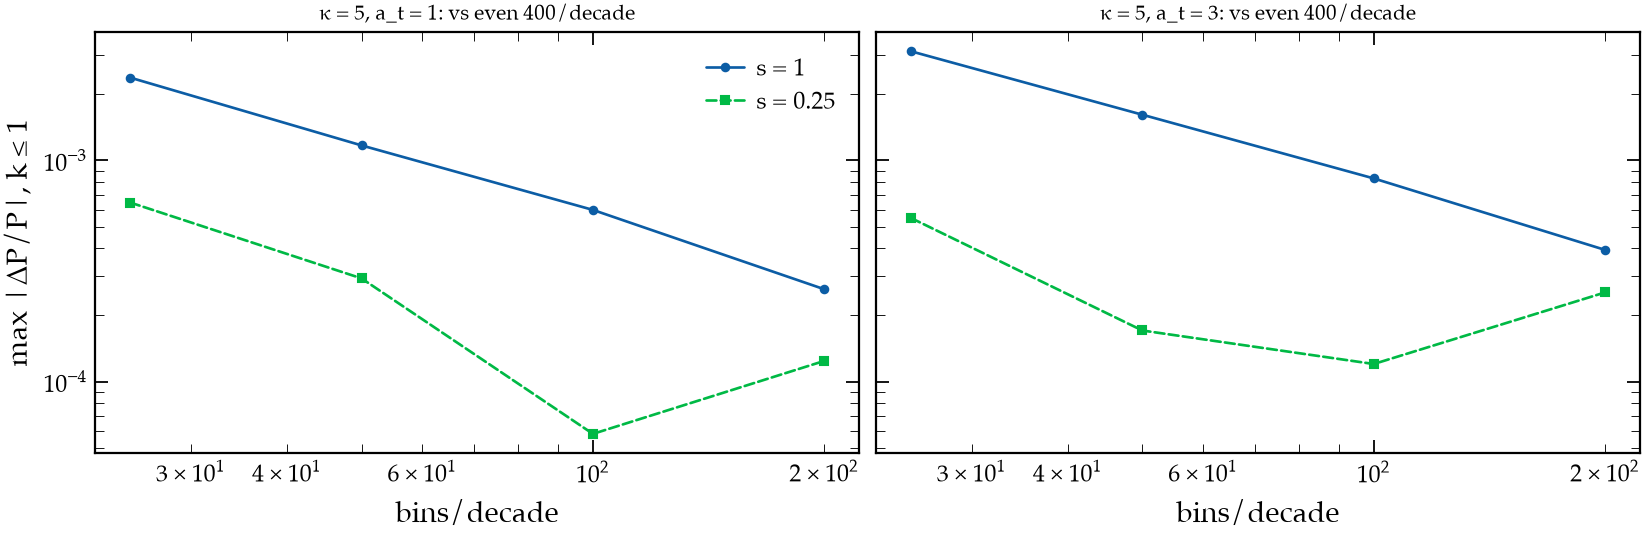

P k≤1   sigma8
a_t s    bins/decade                  
1.0 1.00 25           2.4e-03  1.1e-03
         50           1.2e-03  5.2e-04
         100          6.0e-04  2.2e-04
         200          2.6e-04  7.9e-05
    0.25 25           6.5e-04  2.6e-04
         50           2.9e-04  6.8e-05
         100          5.8e-05  9.5e-06
         200          1.2e-04  4.1e-05
3.0 1.00 25           3.1e-03  1.1e-03
         50           1.6e-03  7.5e-04
         100          8.3e-04  3.1e-04
         200          3.9e-04  1.2e-04
    0.25 25           5.5e-04  2.2e-04
         50           1.7e-04  2.8e-05
         100          1.2e-04  3.7e-05
         200          2.5e-04  7.4e-05

In [5]:
LADDER = [25, 50, 100, 200]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True, constrained_layout=True)
rows = []
for ax, a_t in zip(axes, (1.0, 3.0)):
    top = cache(params(grid(5, bpd=400), 5.0, a_t))
    for share, marker in ((1, 'o-'), (0.25, 's--')):
        recs = cache.many([params(grid(5, bpd=n, share=share), 5.0, a_t) for n in LADDER], verbose=False)
        err = [errors(r, top)['P z=0 k≤1'] for r in recs]
        ax.loglog(LADDER, err, marker, label='s = {:g}'.format(share))
        rows += [{'a_t': a_t, 's': share, 'bins/decade': n, 'P k≤1': e, 'sigma8': errors(r, top)['sigma8']}
                 for n, e, r in zip(LADDER, err, recs)]
    ax.set_title('κ = 5, a_t = {:g}: vs even 400/decade'.format(a_t), fontsize=10)
    ax.set_xlabel('bins/decade')
axes[0].set_ylabel('max |ΔP/P|, k ≤ 1')
axes[0].legend()
plt.show()
show(pd.DataFrame(rows).set_index(['a_t', 's', 'bins/decade']), default='{:.1e}')